# LSTM

Bbox feature LSTM baseline. Per-frame feature is 14-dim (normalized human bbox, object bbox, relative center, IoU, object one-hot). Uses the same 5 folds as the GNN.

## Imports

In [5]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

In [6]:
sys.path.insert(0, str(Path.cwd().parent))

In [7]:
from src.utils.config.config import Config
from src.classifier.common.constants import ACTION_NAMES, OBJECT_CAT_IDS
from src.classifier.common.trainer import BaseTrainer
from src.classifier.lstm.dataset import HOISequenceDataset
from src.classifier.lstm.model import LSTMClassifier

## Config

In [ ]:
SEED = 42

# 4 human bbox + 4 object bbox + 2 dx,dy + 1 IoU + 3 object one-hot
FEATURE_DIM = 4 + 4 + 2 + 1 + len(OBJECT_CAT_IDS)

config_loader = Config()
cfg = config_loader.load_config()
hp = cfg.lstm

dataset_root = cfg.project_root / cfg.paths.dataset / "CafeV1"
clips_root   = dataset_root / "Clips"
folds_path   = dataset_root / "folds.json"
runs_root    = cfg.project_root / "runs" / "lstm"
runs_root.mkdir(parents=True, exist_ok=True)

print(f"device: {cfg.device}")
print(f"feature_dim: {FEATURE_DIM}")
print(f"hp: {hp}")

## Folds

In [9]:
def load_folds(path):
    with open(path) as f:
        return json.load(f)

def split(folds_data, val_fold):
    val = folds_data["folds"][val_fold]
    train = [c for i, f in enumerate(folds_data["folds"]) if i != val_fold for c in f]
    return train, val

def keys_to_dirs(keys, clips_root):
    return [clips_root / k.split("/")[0] / k.split("/")[1] for k in keys]

folds_data = load_folds(folds_path)
K = folds_data["k"]
print(f"loaded {K}-fold split, seed {folds_data['seed']}")

loaded 5-fold split, seed 42


## 5-fold training

In [ ]:
def run_fold(val_fold):
    torch.manual_seed(SEED + val_fold)
    np.random.seed(SEED + val_fold)

    train_keys, val_keys = split(folds_data, val_fold)

    train_set = HOISequenceDataset(
        clips_root, ACTION_NAMES,
        seq_len=hp.seq_len, stride=hp.stride,
        clip_dirs=keys_to_dirs(train_keys, clips_root),
    )
    val_set = HOISequenceDataset(
        clips_root, ACTION_NAMES,
        seq_len=hp.seq_len, stride=hp.stride,
        clip_dirs=keys_to_dirs(val_keys, clips_root),
    )

    model = LSTMClassifier(
        feature_dim=FEATURE_DIM,
        hidden_dim=hp.hidden,
        num_classes=len(ACTION_NAMES),
        num_layers=hp.num_layers,
        dropout=hp.dropout,
    )

    trainer = BaseTrainer(
        model=model,
        dataset=train_set,
        class_names=ACTION_NAMES,
        lr=hp.lr, batch_size=hp.batch_size, epochs=hp.epochs,
        device=cfg.device,
        val_dataset=val_set,
    )

    save_path = runs_root / f"fold{val_fold}_best.pt"
    trainer.fit(save_path=str(save_path))

    trainer.model.load_state_dict(torch.load(save_path, map_location=cfg.device))
    return trainer.evaluate(), trainer.confusion_matrix()

In [11]:
fold_reports = []
fold_cms = []
for k in range(K):
    print(f"\n{'='*60}\nFold {k}\n{'='*60}")
    report, cm = run_fold(k)
    fold_reports.append(report)
    fold_cms.append(cm)
    print(f"\nFold {k} per class F1:")
    for name in ACTION_NAMES:
        print(f"  {name:15s} {report[name]['f1']:.3f}")


Fold 0
Built 2829 sequences from 100 clips (skipped 0)
  Clips with no segments: 0
  Total segments seen: 1519
  Dropped - unknown label: 0
  Dropped - too short (< 16): 503
  Dropped - object category not findable: 0
  Action labels seen: ['idle', 'reading', 'using_laptop', 'using_phone']
  Labels expected: ['idle', 'using_laptop', 'using_phone', 'reading']
Built 720 sequences from 26 clips (skipped 0)
  Clips with no segments: 0
  Total segments seen: 404
  Dropped - unknown label: 0
  Dropped - too short (< 16): 135
  Dropped - object category not findable: 0
  Action labels seen: ['idle', 'reading', 'using_laptop', 'using_phone']
  Labels expected: ['idle', 'using_laptop', 'using_phone', 'reading']
Epoch 1/50 | train_loss=0.5440 train_acc=0.8119 | val_loss=0.1971 val_acc=0.9542
  Saved best model to C:\Research\Prototype\skeleton-based-hoi-recognition\runs\lstm\fold0_best.pt
Epoch 2/50 | train_loss=0.1509 train_acc=0.9664 | val_loss=0.4283 val_acc=0.8861
Epoch 3/50 | train_loss=0.

## Summary

In [12]:
fold_cols = [f"fold_{k}" for k in range(K)]
rows = {fc: [rep[name]["f1"] for name in ACTION_NAMES]
        for fc, rep in zip(fold_cols, fold_reports)}

df = pd.DataFrame(rows, index=ACTION_NAMES)
df.loc["macro"] = df.mean(axis=0)
df["mean"] = df[fold_cols].mean(axis=1)
df["std"]  = df[fold_cols].std(axis=1)
df.round(3)

,fold_0,fold_1,fold_2,fold_3,fold_4,mean,std
idle,0.983,0.992,0.998,1.0,0.986,0.992,0.007
using_laptop,0.919,0.791,1.000,1.0,1.000,0.942,0.092
using_phone,1.000,0.988,0.979,1.0,0.973,0.988,0.012
reading,0.949,0.996,0.963,1.0,0.973,0.976,0.022
macro,0.963,0.942,0.985,1.0,0.983,0.975,0.023


## Confusion matrix

Summed across all 5 folds. Rows are the true class, columns are the predicted class.

In [13]:
total_cm = sum(fold_cms)
cm_df = pd.DataFrame(total_cm, index=ACTION_NAMES, columns=ACTION_NAMES)
cm_df.index.name = "true \\ pred"
cm_df

,idle,using_laptop,using_phone,reading
true \ pred,,,,
idle,1975,3,6,3
using_laptop,5,65,1,0
using_phone,4,3,977,3
reading,10,0,6,488


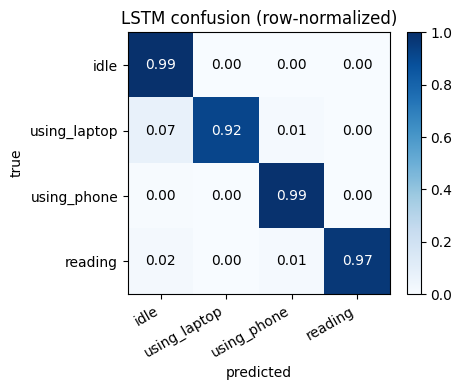

In [14]:
import matplotlib.pyplot as plt

row_sums = total_cm.sum(axis=1, keepdims=True)
norm_cm = total_cm / np.where(row_sums == 0, 1, row_sums)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(norm_cm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(ACTION_NAMES)))
ax.set_yticks(range(len(ACTION_NAMES)))
ax.set_xticklabels(ACTION_NAMES, rotation=30, ha="right")
ax.set_yticklabels(ACTION_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("LSTM confusion (row-normalized)")

for i in range(len(ACTION_NAMES)):
    for j in range(len(ACTION_NAMES)):
        ax.text(j, i, f"{norm_cm[i, j]:.2f}", ha="center", va="center",
                color="white" if norm_cm[i, j] > 0.5 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Save results

In [15]:
from src.classifier.common import results

results.save(
    runs_root / "results.json",
    model_name="lstm",
    action_names=ACTION_NAMES,
    fold_reports=fold_reports,
    fold_cms=fold_cms,
)
print(f"saved {runs_root / 'results.json'}")

saved C:\Research\Prototype\skeleton-based-hoi-recognition\runs\lstm\results.json
